# Visualize The Full Data-Center CFD Field

This notebook loads the Tecplot field written by the FFD solver for the original full data-center layout and plots quick diagnostic slices.

Default file: `../output/full_dc/run/full-thermal-v1/runtime/result.plt`


In [1]:
from pathlib import Path
import os
import re

cache_dir = Path('../output/.matplotlib').resolve()
cache_dir.mkdir(parents=True, exist_ok=True)
os.environ.setdefault('MPLCONFIGDIR', str(cache_dir))

import matplotlib.pyplot as plt
import numpy as np

RESULT_PLT = Path('../output/full_dc/run/full-thermal-v1/runtime/result.plt')
assert RESULT_PLT.exists(), f'Missing field file: {RESULT_PLT}'
Z_SLICE_TARGET_M = 1.5
X_SLICE_TARGET_M = None  # None -> use domain midpoint for YZ slice
RESULT_PLT


WindowsPath('../output/full_dc/run/full-thermal-v1/runtime/result.plt')

In [2]:
def load_result_plt(path: Path):
    lines = path.read_text(encoding='utf-8', errors='replace').splitlines()
    title = lines[0].strip()
    variables_line = lines[1].strip()
    zone_line = lines[2].strip()

    var_match = re.search(r'VARIABLES\s*=\s*(.*)', variables_line)
    if var_match is None:
        raise ValueError(f'Could not parse VARIABLES line: {variables_line}')
    variables = [part.strip() for part in var_match.group(1).split(',')]

    zone_match = re.search(r'I=(\d+),\s*J=(\d+),\s*K=(\d+)', zone_line)
    if zone_match is None:
        raise ValueError(f'Could not parse ZONE line: {zone_line}')
    ni, nj, nk = map(int, zone_match.groups())

    raw = np.loadtxt(path, skiprows=3)
    if raw.ndim != 2 or raw.shape[1] != len(variables):
        raise ValueError(f'Unexpected data shape {raw.shape}; expected {len(variables)} columns')

    data = {name: raw[:, idx] for idx, name in enumerate(variables)}
    data['Speed'] = np.sqrt(data['U']**2 + data['V']**2 + data['W']**2)
    data['shape'] = (nk, nj, ni)
    return title, variables, data


def nearest_plane(values, target):
    unique = np.unique(values)
    return unique[np.argmin(np.abs(unique - target))]


title, variables, data = load_result_plt(RESULT_PLT)
fluid = np.isclose(data['FlagP'], -1.0)
z_target = Z_SLICE_TARGET_M if Z_SLICE_TARGET_M is not None else np.median(data['Z'][fluid])
x_target = X_SLICE_TARGET_M if X_SLICE_TARGET_M is not None else np.median(data['X'][fluid])
z_mid = nearest_plane(data['Z'][fluid], z_target)
x_mid = nearest_plane(data['X'][fluid], x_target)
xy = fluid & np.isclose(data['Z'], z_mid)
yz = fluid & np.isclose(data['X'], x_mid)

print(title)
print(f'Variables: {variables}')
print(f'Fluid points: {fluid.sum():,}')
print(f'Requested XY slice z = {z_target:.3f} m; using nearest grid plane z = {z_mid:.3f} m')
print(f'Requested YZ slice x = {x_target:.3f} m; using nearest grid plane x = {x_mid:.3f} m')
print(f'XY slice points: {xy.sum():,}')
print(f'YZ slice points: {yz.sum():,}')


TITLE = "dt=0.100000s, t=40.000000s, nu=0.000015, Lx=15.000000, Ly=25.000000, Lz=4.500000, Nx=102, Ny=319, Nz=39 "
Variables: ['X', 'Y', 'Z', 'I', 'J', 'K', 'U', 'V', 'W', 'T', 'Xi', 'FlagP', 'P']
Fluid points: 968,218
Requested XY slice z = 1.500 m; using nearest grid plane z = 1.466 m
Requested YZ slice x = 7.425 m; using nearest grid plane x = 7.425 m
XY slice points: 21,744
YZ slice points: 9,127


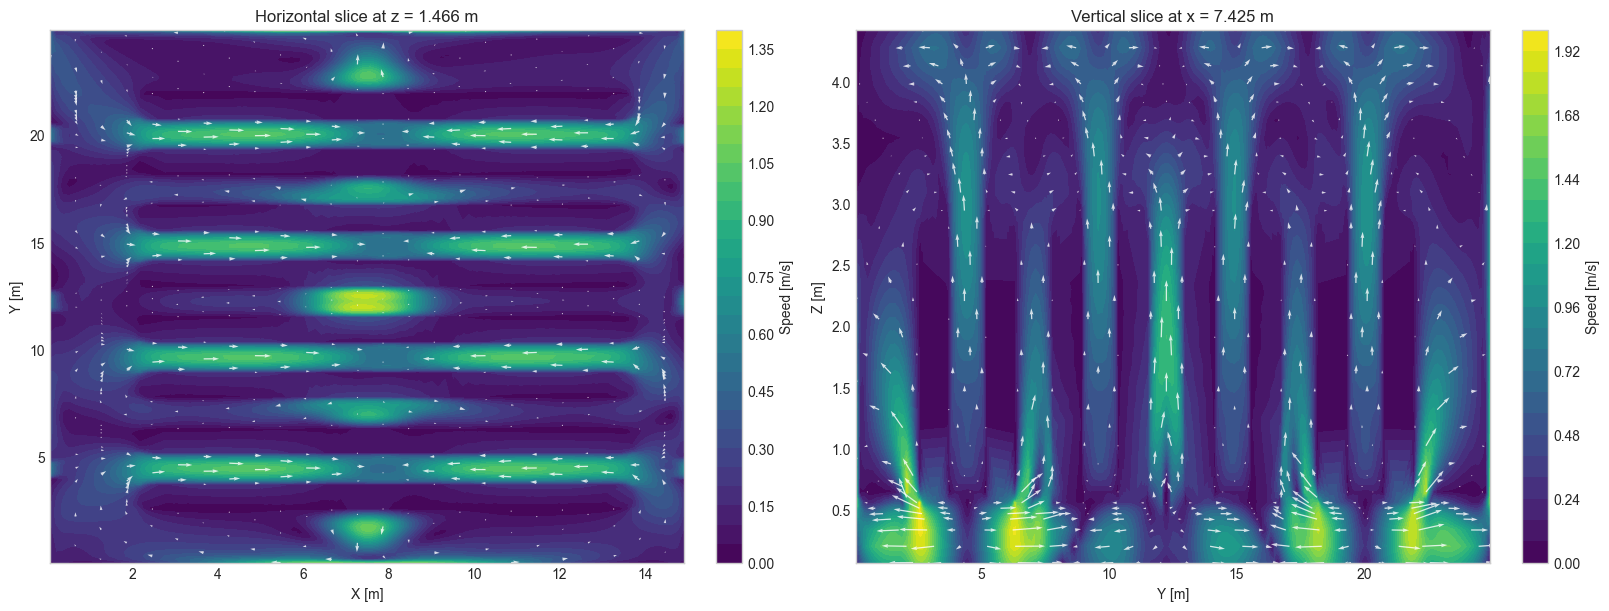

In [3]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

skip_xy = slice(None, None, max(1, xy.sum() // 600))
skip_yz = slice(None, None, max(1, yz.sum() // 600))

cf1 = axes[0].tricontourf(data['X'][xy], data['Y'][xy], data['Speed'][xy], levels=30, cmap='viridis')
axes[0].quiver(
    data['X'][xy][skip_xy],
    data['Y'][xy][skip_xy],
    data['U'][xy][skip_xy],
    data['V'][xy][skip_xy],
    color='white',
    alpha=0.8,
    scale=40,
    width=0.002,
)
axes[0].set_title(f'Horizontal slice at z = {z_mid:.3f} m')
axes[0].set_xlabel('X [m]')
axes[0].set_ylabel('Y [m]')
fig.colorbar(cf1, ax=axes[0], label='Speed [m/s]')

cf2 = axes[1].tricontourf(data['Y'][yz], data['Z'][yz], data['Speed'][yz], levels=30, cmap='viridis')
axes[1].quiver(
    data['Y'][yz][skip_yz],
    data['Z'][yz][skip_yz],
    data['V'][yz][skip_yz],
    data['W'][yz][skip_yz],
    color='white',
    alpha=0.8,
    scale=40,
    width=0.002,
)
axes[1].set_title(f'Vertical slice at x = {x_mid:.3f} m')
axes[1].set_xlabel('Y [m]')
axes[1].set_ylabel('Z [m]')
fig.colorbar(cf2, ax=axes[1], label='Speed [m/s]')

plt.show()


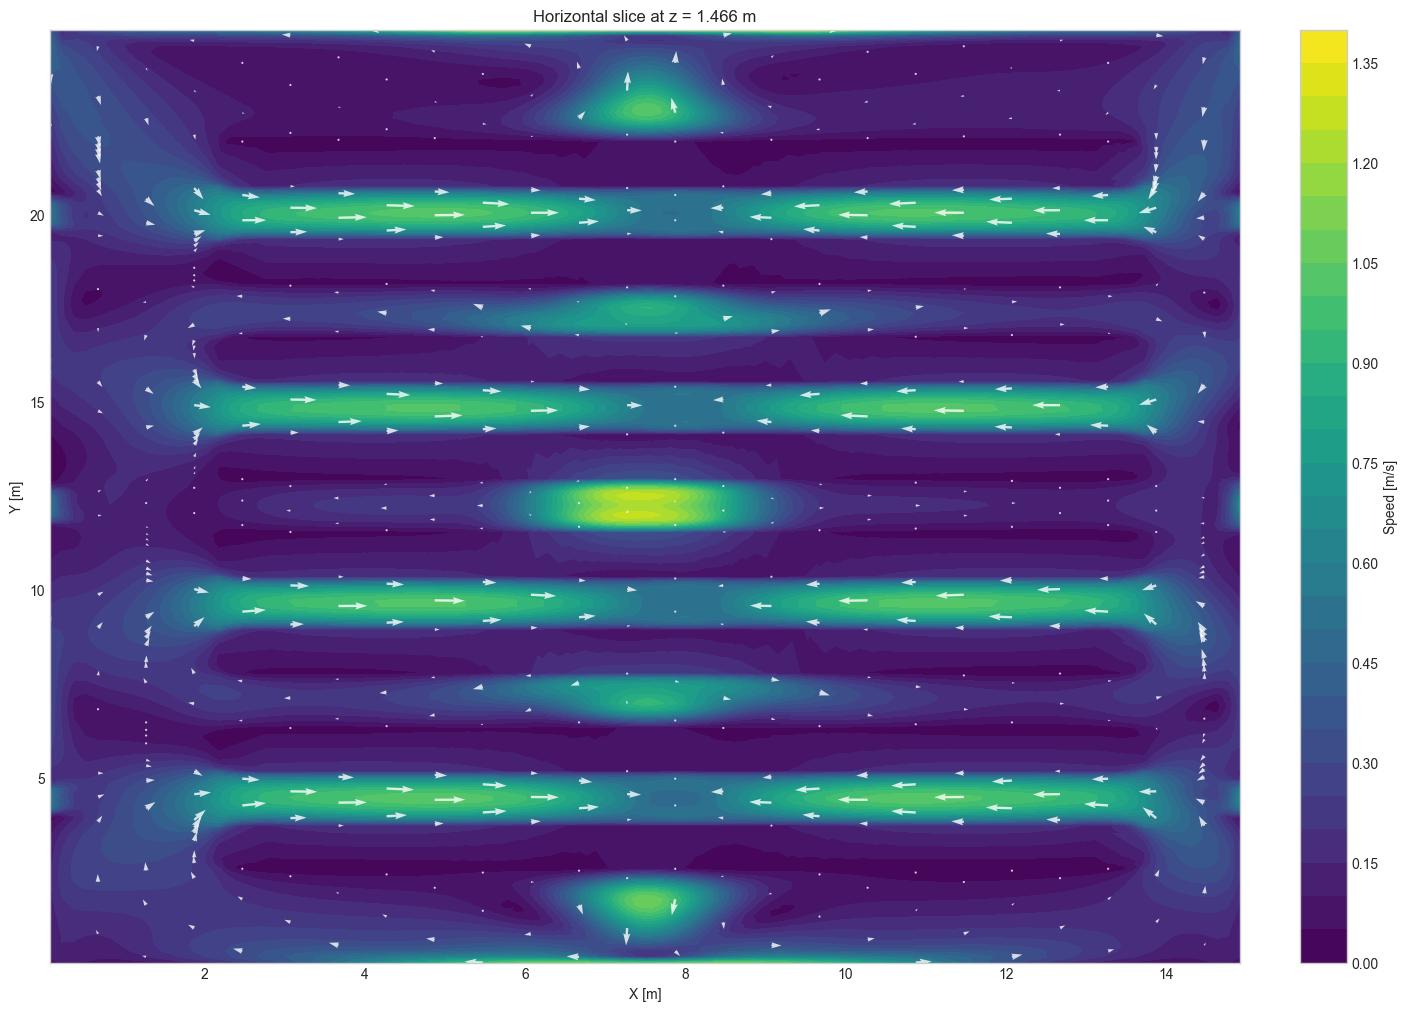

In [14]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 1, figsize=(14, 10), constrained_layout=True)

skip_xy = slice(None, None, max(1, xy.sum() // 600))
skip_yz = slice(None, None, max(1, yz.sum() // 600))

cf1 = axes.tricontourf(data['X'][xy], data['Y'][xy], data['Speed'][xy], levels=30, cmap='viridis')
axes.quiver(
    data['X'][xy][skip_xy],
    data['Y'][xy][skip_xy],
    data['U'][xy][skip_xy],
    data['V'][xy][skip_xy],
    color='white',
    alpha=0.8,
    scale=40,
    width=0.002,
)
axes.set_title(f'Horizontal slice at z = {z_mid:.3f} m')
axes.set_xlabel('X [m]')
axes.set_ylabel('Y [m]')
fig.colorbar(cf1, ax=axes, label='Speed [m/s]')



plt.show()


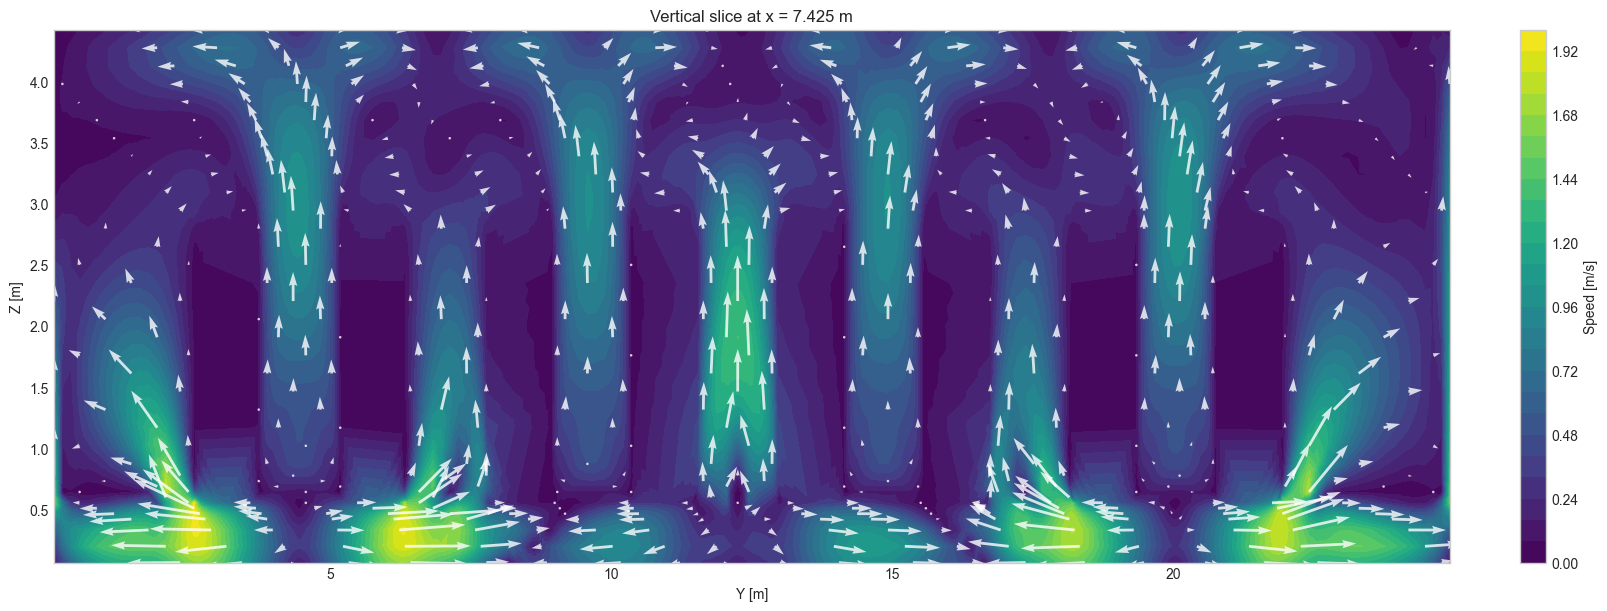

In [13]:
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 1, figsize=(16, 6), constrained_layout=True)

cf2 = axes.tricontourf(data['Y'][yz], data['Z'][yz], data['Speed'][yz], levels=30, cmap='viridis')
axes.quiver(
    data['Y'][yz][skip_yz],
    data['Z'][yz][skip_yz],
    data['V'][yz][skip_yz],
    data['W'][yz][skip_yz],
    color='white',
    alpha=0.8,
    scale=40,
    width=0.002,
)
axes.set_title(f'Vertical slice at x = {x_mid:.3f} m')
axes.set_xlabel('Y [m]')
axes.set_ylabel('Z [m]')
fig.colorbar(cf2, ax=axes, label='Speed [m/s]')


plt.show()

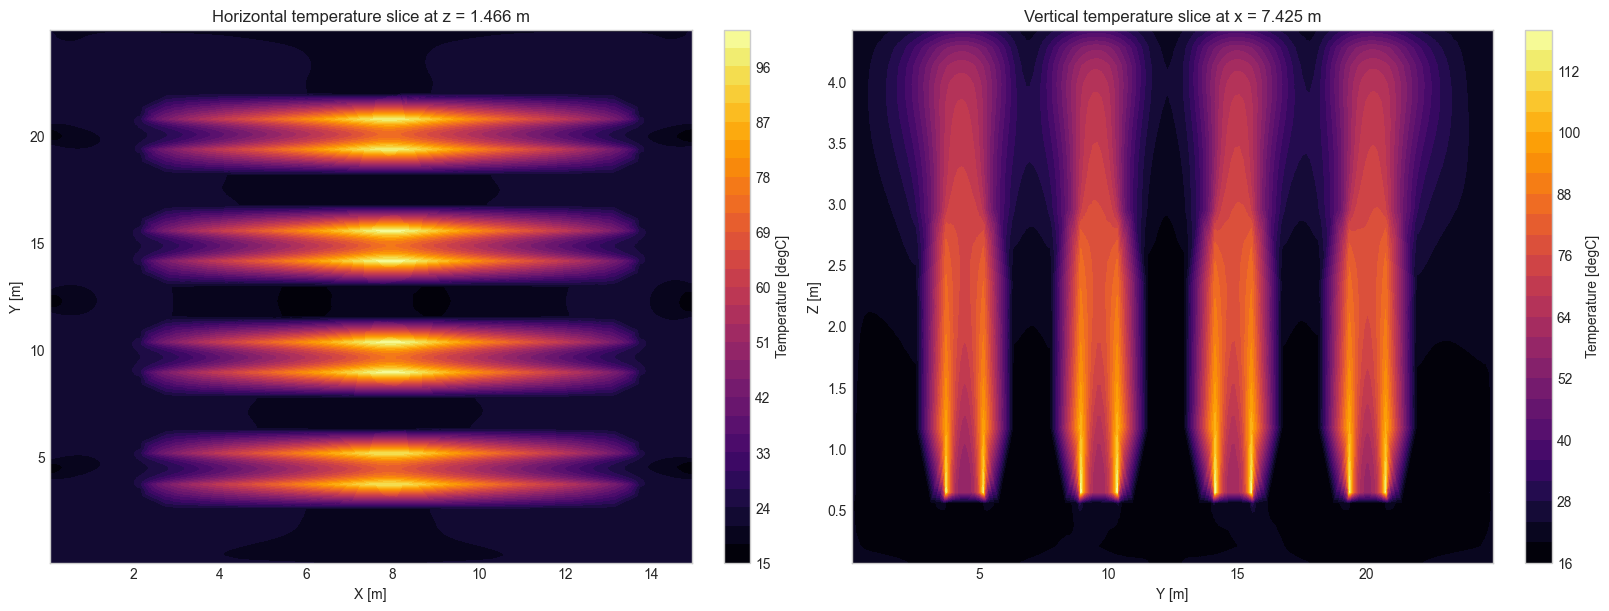

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

ct1 = axes[0].tricontourf(data['X'][xy], data['Y'][xy], data['T'][xy], levels=30, cmap='inferno')
axes[0].set_title(f'Horizontal temperature slice at z = {z_mid:.3f} m')
axes[0].set_xlabel('X [m]')
axes[0].set_ylabel('Y [m]')
fig.colorbar(ct1, ax=axes[0], label='Temperature [degC]')

ct2 = axes[1].tricontourf(data['Y'][yz], data['Z'][yz], data['T'][yz], levels=30, cmap='inferno')
axes[1].set_title(f'Vertical temperature slice at x = {x_mid:.3f} m')
axes[1].set_xlabel('Y [m]')
axes[1].set_ylabel('Z [m]')
fig.colorbar(ct2, ax=axes[1], label='Temperature [degC]')

plt.show()


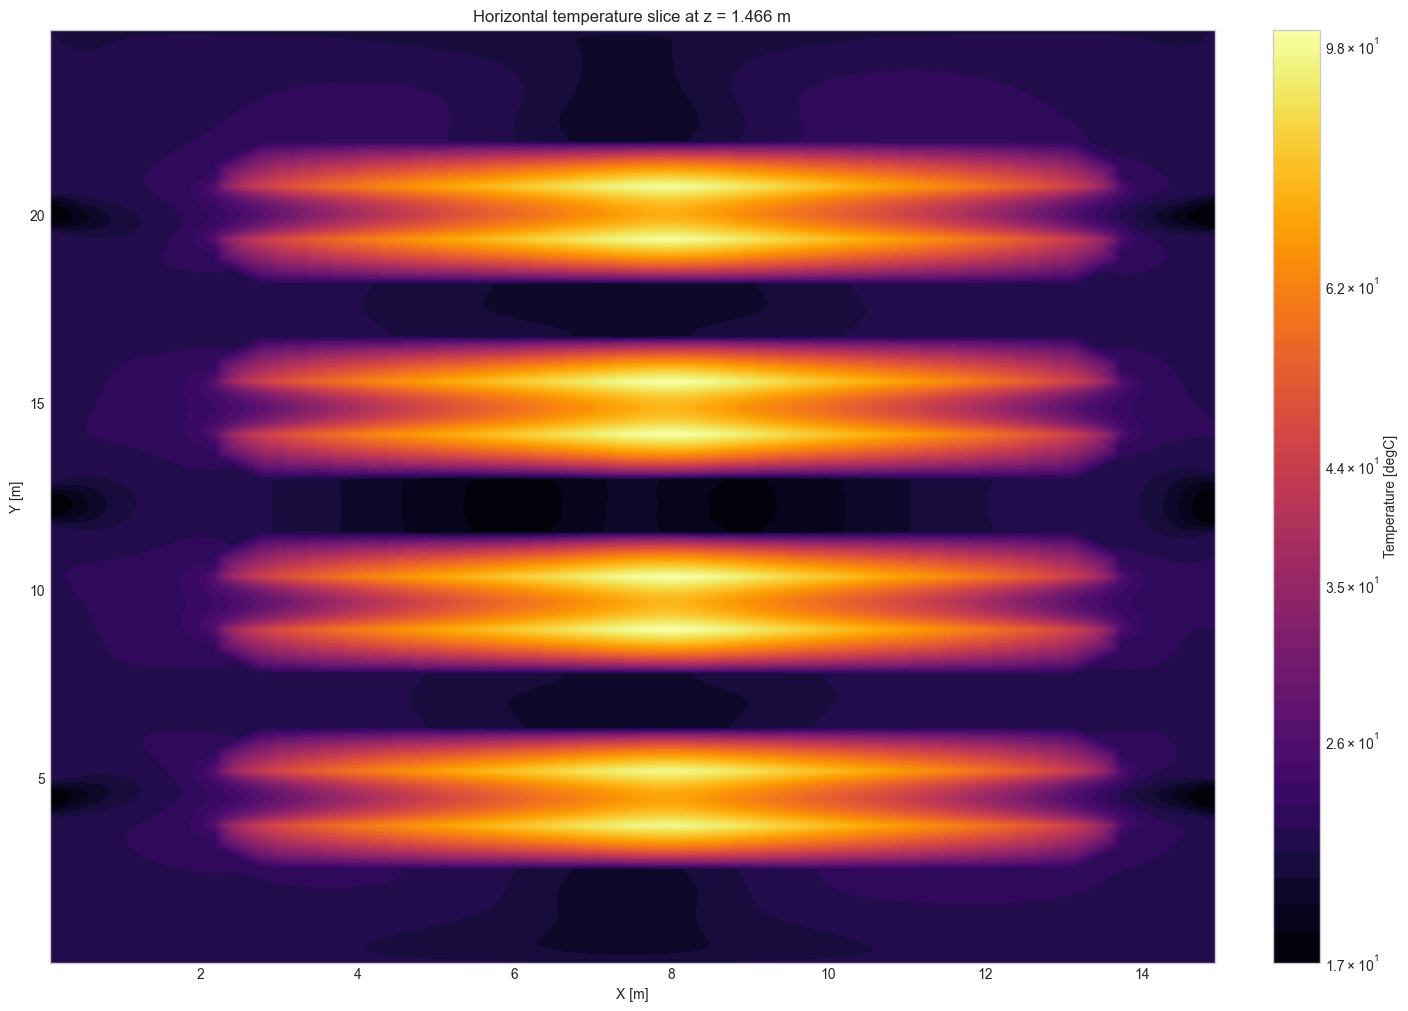

In [25]:
fig, axes = plt.subplots(1, 1, figsize=(14, 10), constrained_layout=True)

ct1 = axes.tricontourf(data['X'][xy], data['Y'][xy], data['T'][xy], levels=100, cmap='inferno', norm='log')
axes.set_title(f'Horizontal temperature slice at z = {z_mid:.3f} m')
axes.set_xlabel('X [m]')
axes.set_ylabel('Y [m]')
fig.colorbar(ct1, ax=axes, label='Temperature [degC]')

plt.show()

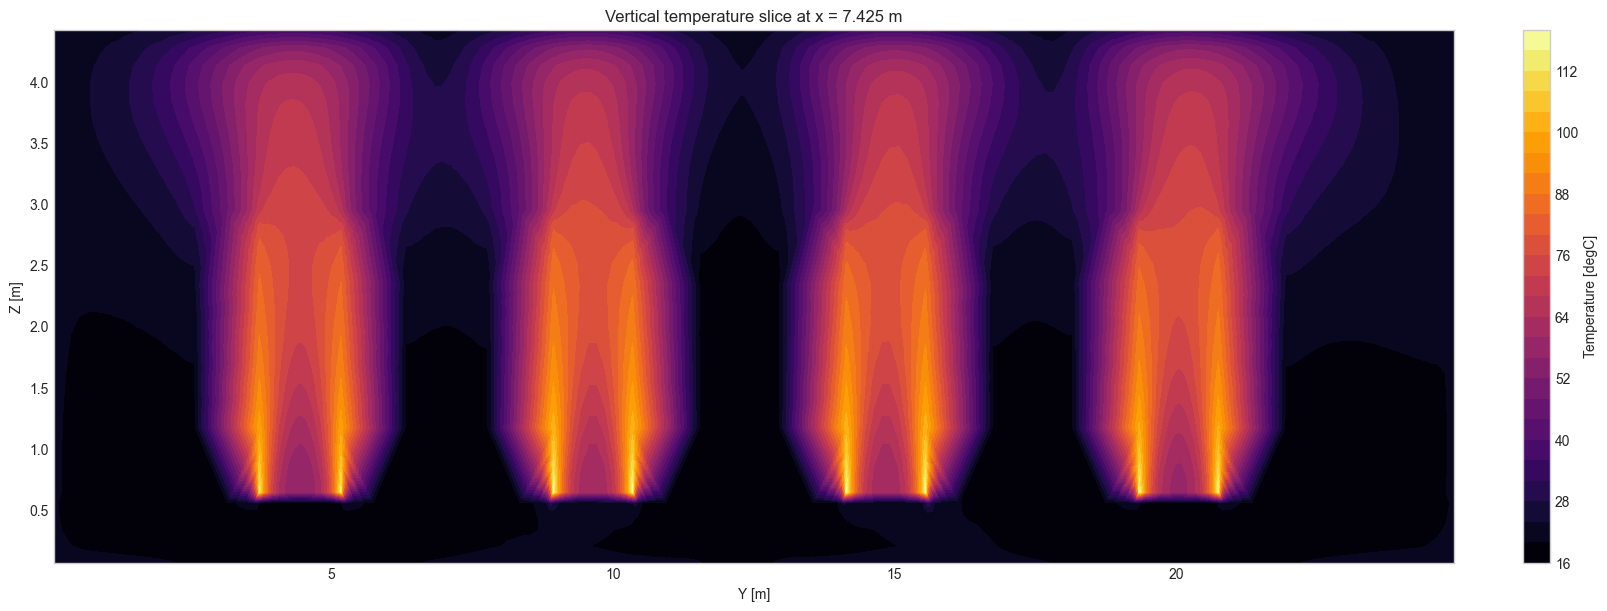

In [27]:
fig, axes = plt.subplots(1, 1, figsize=(16, 6), constrained_layout=True)

ct2 = axes.tricontourf(data['Y'][yz], data['Z'][yz], data['T'][yz], levels=30, cmap='inferno', )
axes.set_title(f'Vertical temperature slice at x = {x_mid:.3f} m')
axes.set_xlabel('Y [m]')
axes.set_ylabel('Z [m]')
fig.colorbar(ct2, ax=axes, label='Temperature [degC]')

plt.show()

## Exact Full-Thermal Slice Set

These cells reproduce the exact validated temperature slices extracted from `full-thermal-v1`: three rack-inlet-height `XY` slices, one room-midplane `YZ` slice, and one room-midplane `XZ` slice.


In [5]:
EXACT_Z_SLICES_M = [0.75, 1.13, 1.51]
EXACT_X_SLICES_M = [7.5]
EXACT_Y_SLICES_M = [12.5]

def exact_plane_mask(axis_name, target):
    actual = nearest_plane(data[axis_name][fluid], target)
    plane = fluid & np.isclose(data[axis_name], actual)
    return actual, plane


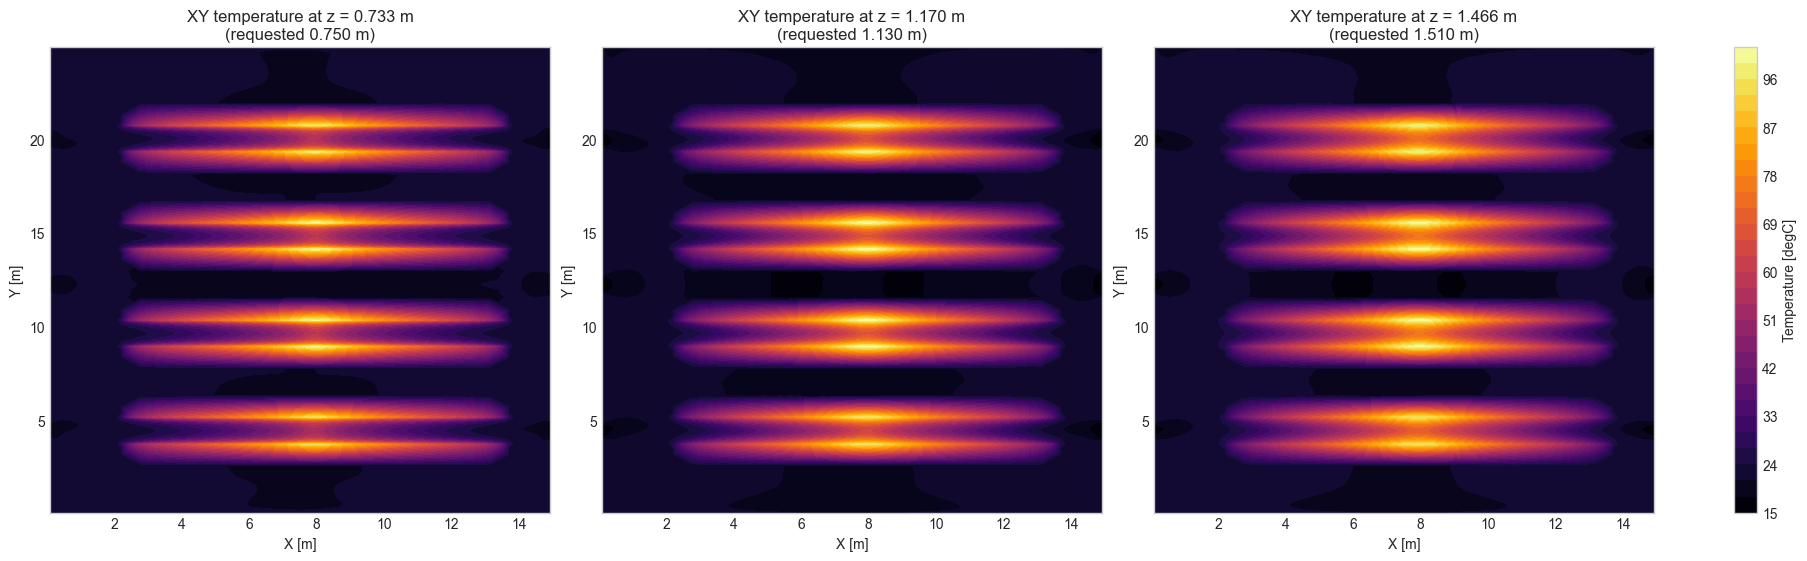

In [6]:
fig, axes = plt.subplots(1, len(EXACT_Z_SLICES_M), figsize=(6 * len(EXACT_Z_SLICES_M), 5.5), constrained_layout=True)
axes = np.atleast_1d(axes)
contours = []

for ax, z_target in zip(axes, EXACT_Z_SLICES_M):
    z_actual, plane = exact_plane_mask('Z', z_target)
    contour = ax.tricontourf(data['X'][plane], data['Y'][plane], data['T'][plane], levels=30, cmap='inferno')
    contours.append(contour)
    ax.set_title(f'XY temperature at z = {z_actual:.3f} m\n(requested {z_target:.3f} m)')
    ax.set_xlabel('X [m]')
    ax.set_ylabel('Y [m]')

fig.colorbar(contours[-1], ax=axes.tolist(), label='Temperature [degC]')
plt.show()


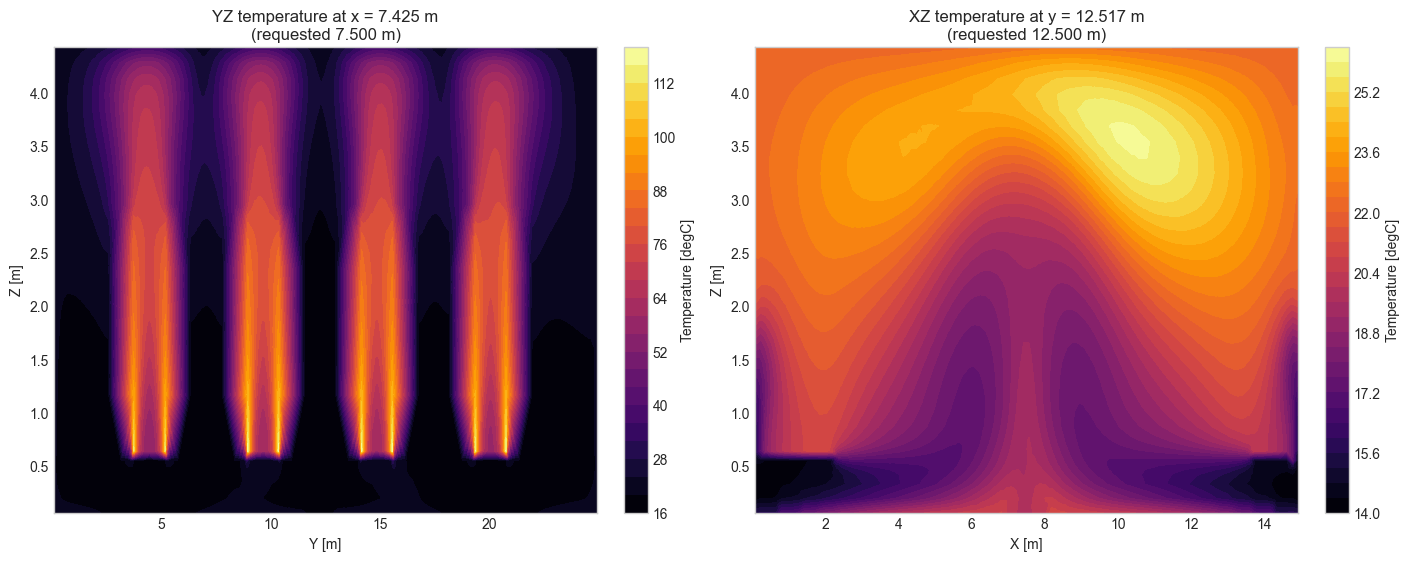

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

x_target = EXACT_X_SLICES_M[0]
x_actual, yz_plane = exact_plane_mask('X', x_target)
contour_yz = axes[0].tricontourf(data['Y'][yz_plane], data['Z'][yz_plane], data['T'][yz_plane], levels=30, cmap='inferno')
axes[0].set_title(f'YZ temperature at x = {x_actual:.3f} m\n(requested {x_target:.3f} m)')
axes[0].set_xlabel('Y [m]')
axes[0].set_ylabel('Z [m]')
fig.colorbar(contour_yz, ax=axes[0], label='Temperature [degC]')

y_target = EXACT_Y_SLICES_M[0]
y_actual, xz_plane = exact_plane_mask('Y', y_target)
contour_xz = axes[1].tricontourf(data['X'][xz_plane], data['Z'][xz_plane], data['T'][xz_plane], levels=30, cmap='inferno')
axes[1].set_title(f'XZ temperature at y = {y_actual:.3f} m\n(requested {y_target:.3f} m)')
axes[1].set_xlabel('X [m]')
axes[1].set_ylabel('Z [m]')
fig.colorbar(contour_xz, ax=axes[1], label='Temperature [degC]')

plt.show()
